In [34]:
# Imports and columns used for the measurement
import pandas as pd
data = pd.read_csv('bank_marketing_clean.csv')
age = data['age']
cpi = data['cons_price_idx']
etm = data['euribor_three_months']

In [35]:
# Compute the range, variance, and standard deviation of the age column
age_range = age.max() - age.min()
age_variance = age.var(ddof=0)
age_std_dev = age.std(ddof=0)

# Show the range, variance, and standard deviation of the age column
print(f"Age Range: {age_range}")
print(f"Age Variance: {age_variance}")
print(f"Age Standard Deviation: {age_std_dev}")

Age Range: 77.0
Age Variance: 96.4372203767313
Age Standard Deviation: 9.820245433630022


In [36]:
# Compute the range, variance, and standard deviation of the cons_price_idx column
cpi_range = cpi.max() - cpi.min()
cpi_variance = cpi.var(ddof=0)
cpi_std_dev = cpi.std(ddof=0)

#Show the range, variance, and standard deviation of the cons_price_idx column
print(f"Cons_Price_Idx Range: {cpi_range}")
print(f"Cons_Price_Idx Variance: {cpi_variance}")
print(f"Cons_Price_Idx Standard Deviation: {cpi_std_dev}")

Cons_Price_Idx Range: 2.5660000000000025
Cons_Price_Idx Variance: 0.3329335457670373
Cons_Price_Idx Standard Deviation: 0.577003939126101


In [37]:
# Compute the range, variance, and standard deviation of the euribor_three_months column
etm_range = etm.max() - etm.min()
etm_variance = etm.var(ddof=0)
etm_std_dev = etm.std(ddof=0)

#Show the range, variance, and standard deviation of the euribor_three_months column
print(f"Euribor_Three_Months Range: {etm_range}")
print(f"Euribor_Three_Months Variance: {etm_variance}")
print(f"Euribor_Three_Months Standard Deviation: {etm_std_dev}")

Euribor_Three_Months Range: 4.411
Euribor_Three_Months Variance: 3.0110936131660497
Euribor_Three_Months Standard Deviation: 1.735250302741956


In [56]:
# Function to convert [H:M:S] to total seconds
def convert_to_seconds(time_str):
    h, m, s = map(int, time_str.split(':'))  # Split string into hours, minutes, seconds
    return h * 3600 + m * 60 + s  # Convert to total seconds
data['contact_duration_secs'] = data['contact_duration'].apply(convert_to_seconds)

cd = data['contact_duration_secs']

# Compute the range, variance, and standard deviation of the contact_duration column
cd_range = cd.max() - cd.min()
cd_variance = cd.var(ddof=0)
cd_std_dev = cd.std(ddof=0)

print(cd_range)
print(cd_variance)


3507
66609.71729572299
258.0885842026396


In [64]:
# Function to convert [H:M:S] to total seconds
def convert_to_seconds(time_str):
    h, m, s = map(int, time_str.split(':'))  # Split string into hours, minutes, seconds
    return h * 3600 + m * 60 + s  # Convert to total seconds
data['contact_duration_secs'] = data['contact_duration'].apply(convert_to_seconds)

cd = data['contact_duration_secs']

# Compute the range, variance, and standard deviation of the contact_duration column
cd_range = cd.max() - cd.min()
cd_variance = cd.var(ddof=0)
cd_std_dev = cd.std(ddof=0)

# Function to convert total seconds back to [H:M:S] format
def convert_seconds_to_hms(total_seconds):
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours:02}:{minutes:02}:{seconds:02}"  # Format as HH:MM:SS

# Convert range, variance, and std deviation back to [H:M:S] format
range_hms = convert_seconds_to_hms(cd_range)
variance_hms = convert_seconds_to_hms(int(cd_variance))  # Convert float to int for formatting
std_dev_hms = convert_seconds_to_hms(int(cd_std_dev))

# Display results in [H:M:S] format
print(f"Range of Contact Duration: {range_hms}")
print(f"Variance of Contact Duration (approx.): {variance_hms}")
print(f"Standard Deviation of Contact Duration: {std_dev_hms}")


Range of Contact Duration: 00:58:27
Variance of Contact Duration (approx.): 18:30:09
Standard Deviation of Contact Duration: 00:04:18


In [42]:
nc = data['number_contacts']
pcc = data['previous_campaign_contacts']

# Compute the range, variance, and standard deviation of the number_contacts column
nc_range = nc.max() - nc.min()
nc_variance = nc.var(ddof=0)
nc_std_dev = nc.std(ddof=0)
cv_nc = (nc_std_dev / nc.mean()) * 100

#Show the range, variance, and standard deviation of the number_contacts column
print(f"Number_Contact Range: {nc_range}")
print(f"Number_Contact Variance: {nc_variance}")
print(f"Number_Contact Standard Deviation: {nc_std_dev}")
print(f"CV of Number_Contact: {cv_nc:.2f}%")

# Compute the range, variance, and standard deviation of the previous_campaign_contacts column
pcc_range = pcc.max() - pcc.min()
pcc_variance = pcc.var(ddof=0)
pcc_std_dev = pcc.std(ddof=0)
pcc_cv = (pcc_std_dev / pcc.mean()) * 100

#Show the range, variance, and standard deviation of the previous_campaign_contacts column
print(f"Previous_Campaign_Contacts Range: {pcc_range}")
print(f"Previous_Campaign_Contacts: {pcc_variance}")
print(f"Previous_Campaign_Contacts Deviation: {pcc_std_dev}")
print(f"CV of Previous_Campaign_Contacts: {pcc_cv:.2f}%")

Number_Contact Range: 55
Number_Contact Variance: 8.171507711911358
Number_Contact Standard Deviation: 2.8585849142383997
CV of Number_Contact: 111.19%
Previous_Campaign_Contacts Range: 6
Previous_Campaign_Contacts: 0.2541563545706371
Previous_Campaign_Contacts Deviation: 0.5041392214167006
CV of Previous_Campaign_Contacts: 287.30%


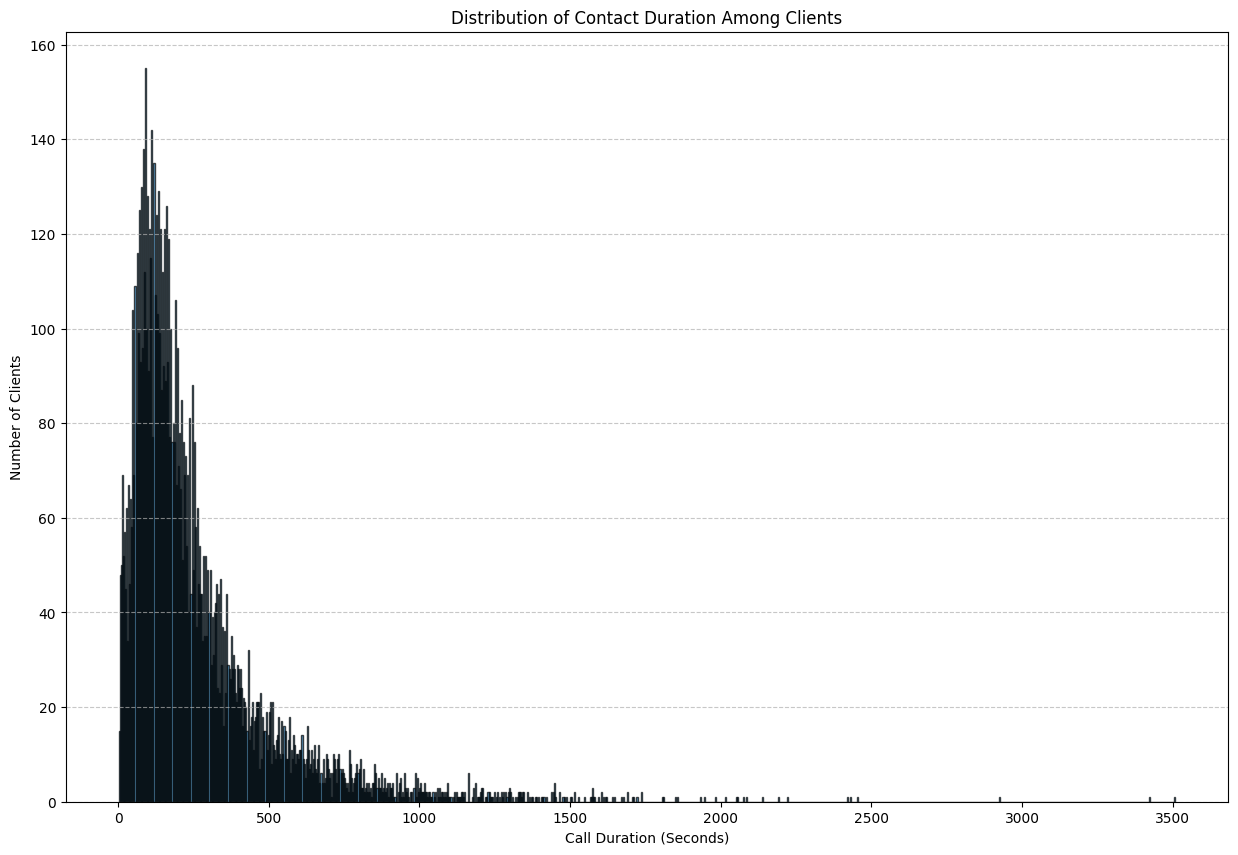

In [66]:
import matplotlib.pyplot as plt

# Create a histogram
plt.figure(figsize=(15, 10))
plt.hist(data['contact_duration_secs'], bins=1000, edgecolor="black", alpha=0.7)
plt.xlabel("Call Duration (Seconds)")
plt.ylabel("Number of Clients")
plt.title("Distribution of Contact Duration Among Clients")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

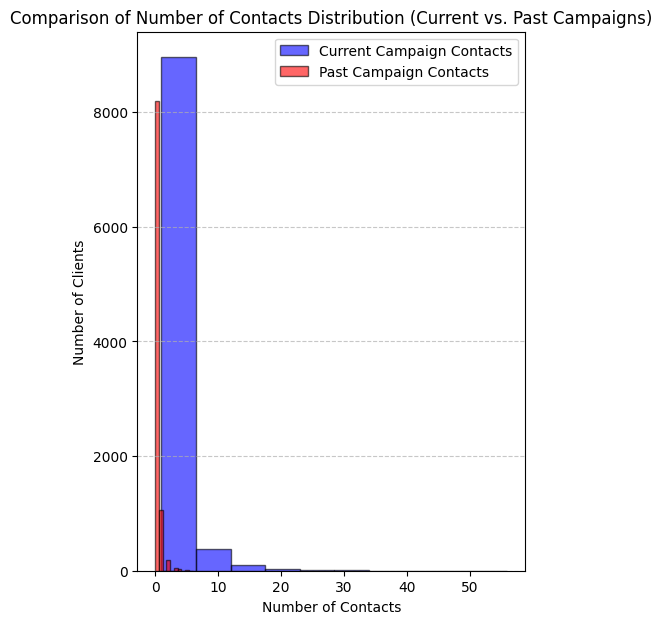

In [75]:
import matplotlib.pyplot as plt

# Plot histogram for number_contacts (current campaign) and previous_campaign_contacts (past campaigns)
plt.figure(figsize=(5, 7))
plt.hist(data["number_contacts"], bins=10, alpha=0.6, label="Current Campaign Contacts", color="blue", edgecolor="black")
plt.hist(data["previous_campaign_contacts"], bins=10, alpha=0.6, label="Past Campaign Contacts", color="red", edgecolor="black")

# Labels and legend
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Clients")
plt.title("Comparison of Number of Contacts Distribution (Current vs. Past Campaigns)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


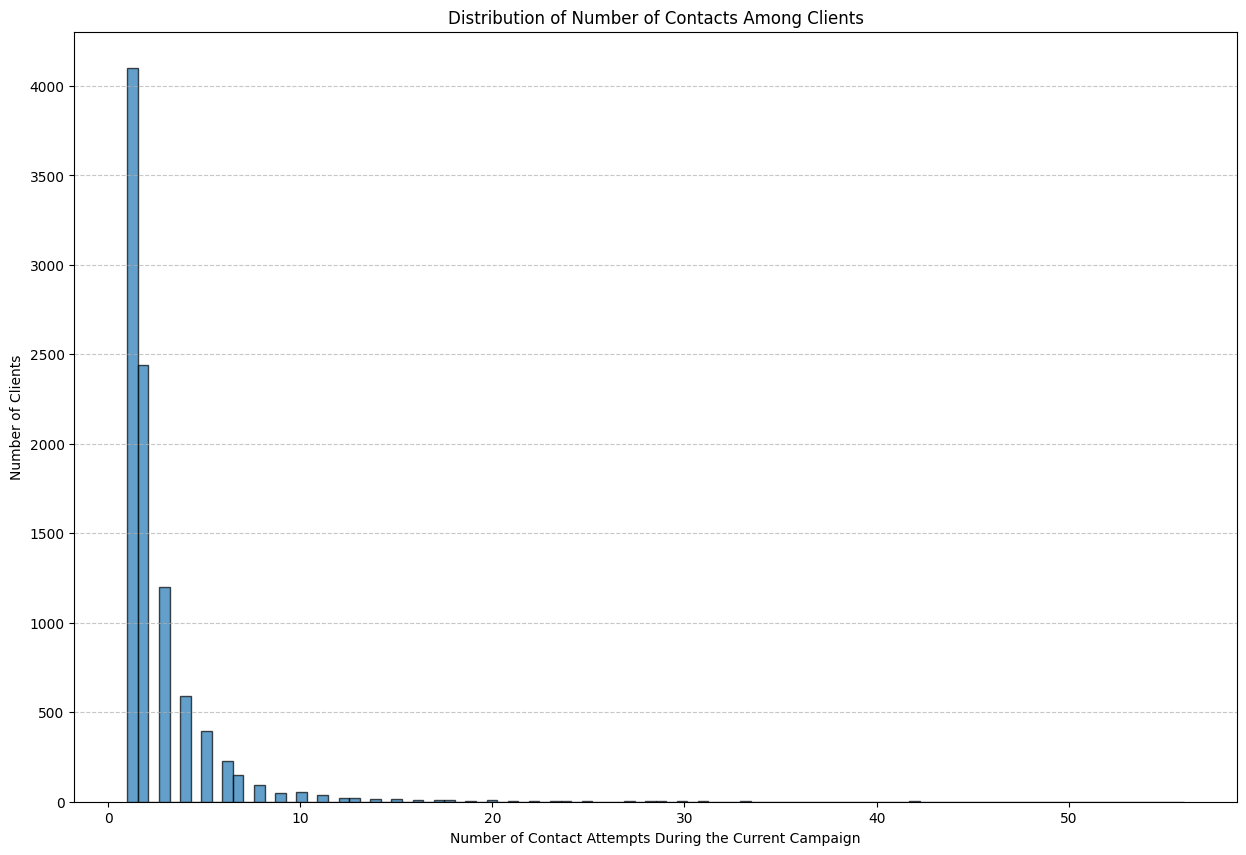

In [82]:
# Create a histogram
plt.figure(figsize=(15, 10))
plt.hist(data['number_contacts'], bins=100, edgecolor="black", alpha=0.7)
plt.xlabel("Number of Contact Attempts During the Current Campaign")
plt.ylabel("Number of Clients")
plt.title("Distribution of Number of Contacts Among Clients")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

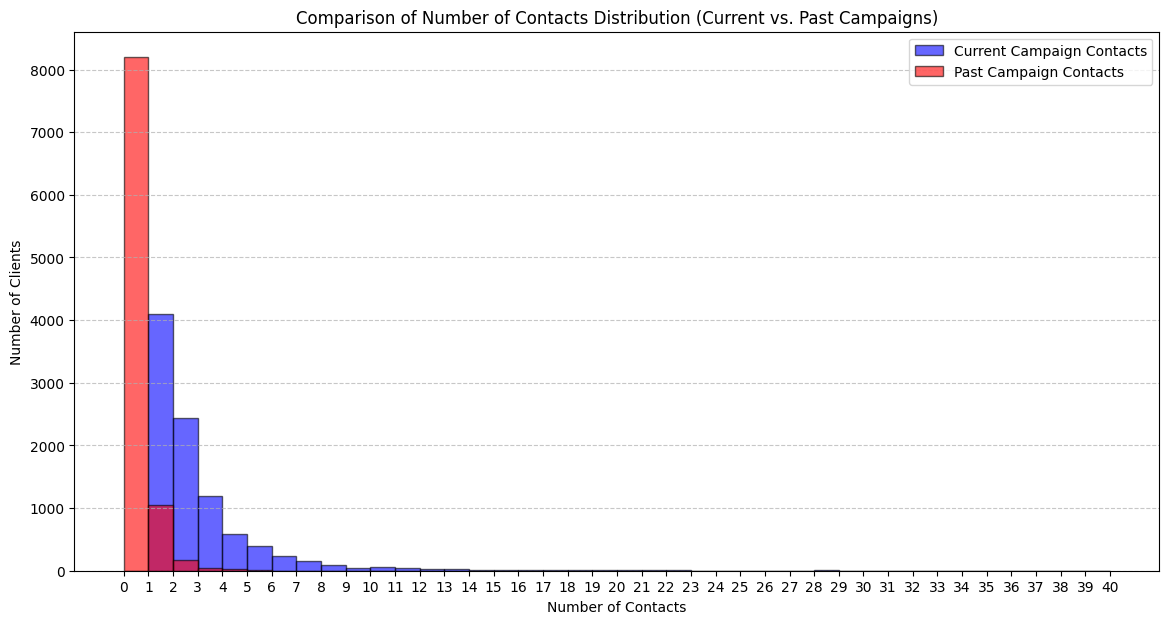

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range of the histogram based on the data
min_val = min(data["number_contacts"].min(), data["previous_campaign_contacts"].min())  # Smallest value
max_val = max(data["number_contacts"].max(), data["previous_campaign_contacts"].max())  # Largest value

# Create integer bins
bins = np.arange(min_val, 41)  # +2 to include the last bin edge

# Plot histogram for number_contacts (current campaign) and previous_campaign_contacts (past campaigns)
plt.figure(figsize=(14, 7))
plt.hist(data["number_contacts"], bins=bins, alpha=0.6, label="Current Campaign Contacts", color="blue",
         edgecolor="black")
plt.hist(data["previous_campaign_contacts"], bins=bins, alpha=0.6, label="Past Campaign Contacts", color="red",
         edgecolor="black")

# Labels and legend
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Clients")
plt.title("Comparison of Number of Contacts Distribution (Current vs. Past Campaigns)")
plt.legend()

# Set x-ticks for every integer
plt.xticks(bins)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

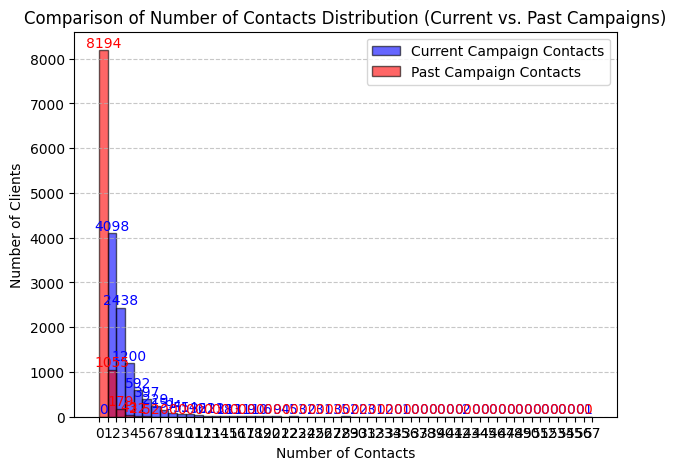

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range of the histogram based on the data
min_val = min(data["number_contacts"].min(), data["previous_campaign_contacts"].min())  # Smallest value
max_val = max(data["number_contacts"].max(), data["previous_campaign_contacts"].max())  # Largest value

# Create integer bins
bins = np.arange(min_val, max_val + 2)  # +2 to include the last bin edge

# Plot the histogram
plt.figure(figsize=(7, 5))
hist1 = plt.hist(data["number_contacts"], bins=bins, alpha=0.6, label="Current Campaign Contacts", color="blue",
                 edgecolor="black")
hist2 = plt.hist(data["previous_campaign_contacts"], bins=bins, alpha=0.6, label="Past Campaign Contacts", color="red",
                 edgecolor="black")

# Add labels to the bars for the first histogram
for rect, count in zip(hist1[2], hist1[0]):  # hist1[2] are the bar patches, hist1[0] are the heights
    height = count
    plt.text(rect.get_x() + rect.get_width() / 2, height,  # Center of each bar
             f"{int(height)}",  # Format the count as an integer
             ha='center', va='bottom', fontsize=10, color="blue")

# Add labels to the bars for the second histogram
for rect, count in zip(hist2[2], hist2[0]):  # hist2[2] are the bar patches, hist2[0] are the heights
    height = count
    plt.text(rect.get_x() + rect.get_width() / 2, height,  # Center of each bar
             f"{int(height)}",  # Format the count as an integer
             ha='center', va='bottom', fontsize=10, color="red")

# Labels and legend
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Clients")
plt.title("Comparison of Number of Contacts Distribution (Current vs. Past Campaigns)")
plt.legend()

# Set x-ticks for every integer
plt.xticks(bins)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()
